# 🔗 Hands-On Bab 1 — Pendahuluan
### Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi
*Warih Maharani, Fitriyani, Agung Toto Wibowo*

Notebook ini adalah pendamping praktik untuk **Bab 1: Pendahuluan**. Anda akan:
- Membangun graf sederhana G = (V, E) dengan NetworkX
- Mereproduksi ilustrasi struktur inti-perifer, simpul jembatan, dan difusi informasi dari buku
- Mengerjakan seluruh **Latihan Soal Bab 1**



In [2]:
!pip install -q networkx matplotlib
import networkx as nx
import matplotlib.pyplot as plt
print("NetworkX version:", nx.__version__)

NetworkX version: 3.6.1


## 1.1 Definisi Jaringan

Jaringan direpresentasikan sebagai graf **G = (V, E)**:
- **V (simpul/node)** — himpunan entitas (individu, organisasi, objek)
- **E (sisi/edge)** — himpunan relasi antarsimpul (komunikasi, kolaborasi, dsb.)

Mari kita bangun graf sederhana yang merepresentasikan lima mahasiswa dan relasi diskusi mereka (Contoh 1.1 di buku).

Jumlah simpul |V| = 5
Jumlah sisi   |E| = 5


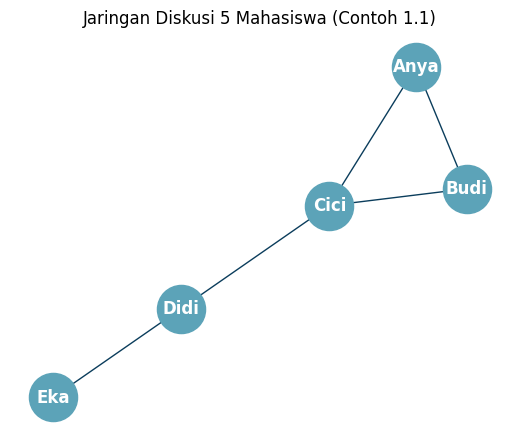

In [3]:
G = nx.Graph()
G.add_nodes_from(["Anya", "Budi", "Cici", "Didi", "Eka"])
G.add_edges_from([
    ("Anya", "Budi"), ("Anya", "Cici"), ("Budi", "Cici"),
    ("Cici", "Didi"), ("Didi", "Eka")
])

print("Jumlah simpul |V| =", G.number_of_nodes())
print("Jumlah sisi   |E| =", G.number_of_edges())

plt.figure(figsize=(5, 4))
nx.draw(G, with_labels=True, node_color="#5CA3B8", node_size=1200,
        font_color="white", font_weight="bold", edge_color="#0B3D5C")
plt.title("Jaringan Diskusi 5 Mahasiswa (Contoh 1.1)")
plt.show()

## 1.3.1 Ilustrasi Struktur Inti-Perifer (Gambar 1.1)

Pada buku, sebuah kelas berisi 20 mahasiswa memiliki kelompok inti (5 orang, saling terhubung padat) dan simpul perifer yang hanya terhubung ke inti lewat satu-dua perantara. Mari kita reproduksi strukturnya secara sederhana dan lihat siapa yang paling sentral.

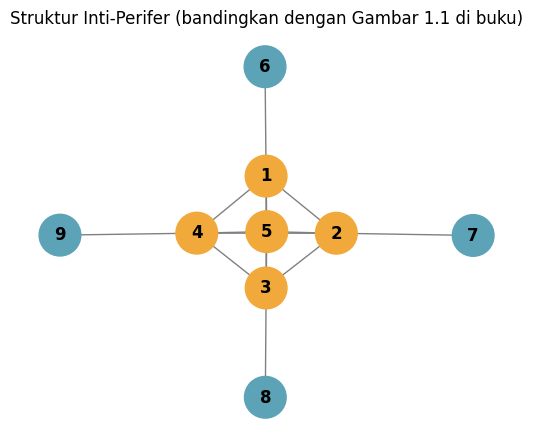

Degree tiap simpul: {1: 5, 2: 5, 3: 5, 4: 5, 5: 4, 6: 1, 7: 1, 8: 1, 9: 1}
Simpul paling sentral (degree tertinggi): 1


In [4]:
inti_perifer = nx.Graph()
inti = [1, 2, 3, 4, 5]
perifer = [6, 7, 8, 9]

# Kelompok inti saling terhubung padat
inti_perifer.add_edges_from([(a, b) for i, a in enumerate(inti) for b in inti[i+1:]])
# Simpul perifer hanya terhubung ke 1-2 simpul inti
inti_perifer.add_edges_from([(6, 1), (7, 2), (8, 3), (9, 4)])

pos = nx.spring_layout(inti_perifer, seed=42)
colors = ["#F2A93B" if n in inti else "#5CA3B8" for n in inti_perifer.nodes()]
plt.figure(figsize=(5, 4))
nx.draw(inti_perifer, pos, with_labels=True, node_color=colors, node_size=900,
        font_weight="bold", edge_color="gray")
plt.title("Struktur Inti-Perifer (bandingkan dengan Gambar 1.1 di buku)")
plt.show()

# Simpul mana yang paling sentral? (pratinjau konsep Bab 4)
degree_dict = dict(inti_perifer.degree())
print("Degree tiap simpul:", degree_dict)
print("Simpul paling sentral (degree tertinggi):", max(degree_dict, key=degree_dict.get))

## 1.3.2 Ilustrasi Simpul Jembatan / Broker (Gambar 1.2, Contoh 1.3)

Staf bernama **Andi** menghubungkan tiga divisi berbeda yang jika tidak lewat dia, tidak saling terhubung. Mari kita bangun jaringan ini dan gunakan `betweenness_centrality` (dibahas formal di Bab 4) untuk membuktikan Andi adalah jembatan utama.

Top-5 Betweenness Centrality:
  Andi: 0.750
  A1: 0.389
  B1: 0.389
  C1: 0.389
  A2: 0.000


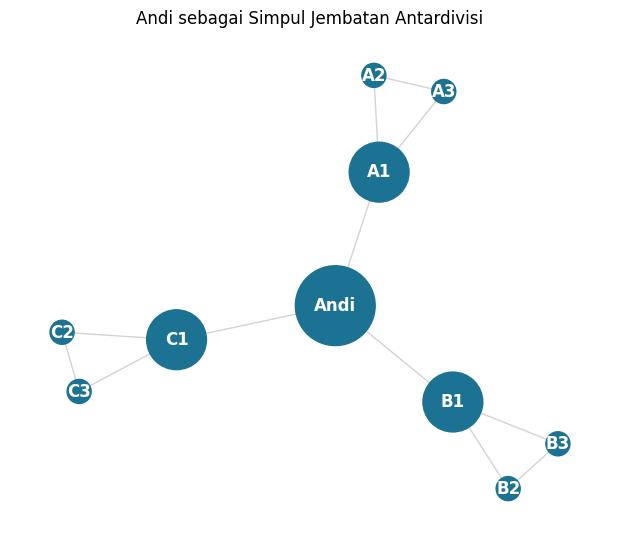

In [5]:
G_org = nx.Graph()
divisi_a = ["A1", "A2", "A3"]
divisi_b = ["B1", "B2", "B3"]
divisi_c = ["C1", "C2", "C3"]

for div in [divisi_a, divisi_b, divisi_c]:
    G_org.add_edges_from([(div[i], div[j]) for i in range(len(div)) for j in range(i+1, len(div))])

# Andi menjadi satu-satunya penghubung antardivisi
G_org.add_edges_from([("Andi", "A1"), ("Andi", "B1"), ("Andi", "C1")])

betweenness = nx.betweenness_centrality(G_org)
sorted_bw = sorted(betweenness.items(), key=lambda x: -x[1])
print("Top-5 Betweenness Centrality:")
for node, val in sorted_bw[:5]:
    print(f"  {node}: {val:.3f}")

pos = nx.spring_layout(G_org, seed=7)
sizes = [4000*betweenness[n] + 300 for n in G_org.nodes()]
plt.figure(figsize=(6, 5))
nx.draw(G_org, pos, with_labels=True, node_size=sizes, node_color="#1C7293",
        font_color="white", font_weight="bold", edge_color="lightgray")
plt.title("Andi sebagai Simpul Jembatan Antardivisi")
plt.show()

Ukuran simpul pada gambar di atas proporsional terhadap betweenness centrality-nya — perhatikan betapa jauh lebih besar simpul **Andi** dibandingkan simpul lain (telah dijelaskan pada Contoh 1.3.).

## 1.3.3 Ilustrasi Difusi Informasi (Gambar 1.3, Contoh 1.4)

Contoh 1.4 pada buku menggambarkan tren "kopi susu kekinian" yang menyebar bertahap dari Rina (t=0) ke seluruh kantor (t=4). Mari simulasikan proses information cascade sederhana ini.

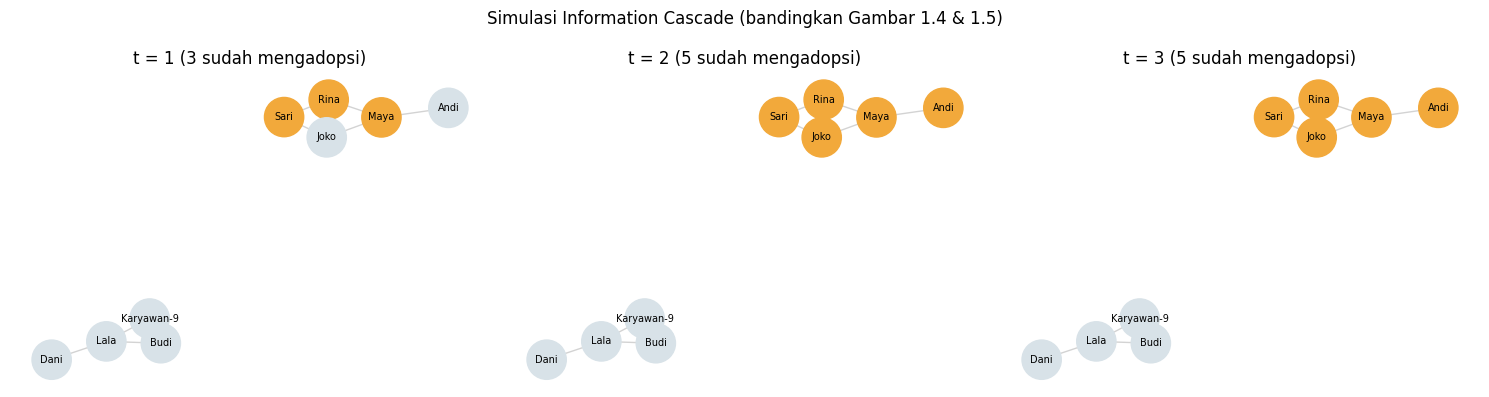

In [6]:
import random

G_diffusion = nx.watts_strogatz_graph(9, 3, 0.3, seed=3)
labels = {0: "Rina", 1: "Andi", 2: "Maya", 3: "Joko", 4: "Sari",
          5: "Dani", 6: "Lala", 7: "Budi", 8: "Karyawan-9"}
G_diffusion = nx.relabel_nodes(G_diffusion, labels)

adopters = {"Rina"}
pos = nx.spring_layout(G_diffusion, seed=3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for t, ax in enumerate(axes):
    # setiap langkah waktu, tetangga dari adopter ikut mengadopsi
    new_adopters = set(adopters)
    for node in adopters:
        new_adopters.update(G_diffusion.neighbors(node))
    adopters = new_adopters
    colors = ["#F2A93B" if n in adopters else "#D8E2E8" for n in G_diffusion.nodes()]
    nx.draw(G_diffusion, pos, ax=ax, with_labels=True, node_color=colors,
            node_size=800, font_size=7, edge_color="lightgray")
    ax.set_title(f"t = {t+1} ({len(adopters)} sudah mengadopsi)")
plt.suptitle("Simulasi Information Cascade (bandingkan Gambar 1.4 & 1.5)")
plt.tight_layout()
plt.show()

## ✅ Latihan Soal Bab 1

Kerjakan seluruh soal berikut. Untuk soal konseptual, tulis jawaban Anda pada sel Markdown yang disediakan. Untuk soal 5, lengkapi kode pada sel kode.

**1.** Apa perbedaan utama antara analisis data statistik konvensional dengan AJS?

**2.** Dalam sebuah graf jaringan sosial, apa yang direpresentasikan oleh simpul dan apa yang direpresentasikan oleh sisi? Berikan tiga contoh nyata.

**3.** Jika Anda ingin menganalisis penyebaran hoaks di media sosial, elemen apa yang akan menjadi simpul dan relasi apa yang menjadi sisi?

**4.** Mengapa relasi antarentitas sering kali lebih penting daripada atribut individu dalam memahami fenomena sosial?

**5.** Sebutkan lima sistem sehari-hari yang dapat dimodelkan sebagai jaringan, mencakup identifikasi simpul dan sisi. **Bangun salah satunya dengan NetworkX pada sel kode di bawah.**

### ✏️ Jawaban Soal 1–4 (tulis di sini)

_1._

_2._

_3._

_4._

In [ ]:
# Soal 5 — TODO: ganti dengan sistem pilihan Anda sendiri
# Contoh kerangka: jaringan rute penerbangan antarkota

G_soal5 = nx.Graph()
# TODO: tambahkan simpul (kota/entitas pilihan Anda)
G_soal5.add_nodes_from(["Kota A", "Kota B", "Kota C"])
# TODO: tambahkan sisi (relasi/rute pilihan Anda)
G_soal5.add_edges_from([("Kota A", "Kota B"), ("Kota B", "Kota C")])

plt.figure(figsize=(4, 3))
nx.draw(G_soal5, with_labels=True, node_color="#5CA3B8", node_size=1000, font_weight="bold")
plt.title("Jaringan Pilihan Saya (Soal 5)")
plt.show()

---
### 📚 Referensi
Bab 1 — *Pendahuluan*, dalam **Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi** (Maharani, Fitriyani, & Wibowo).

Lanjutkan ke **Notebook Bab 2 — Konsep Dasar** untuk mempelajari struktur dan karakteristik jaringan secara formal.